In [5]:
import os
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from langchain_core.messages import AIMessage, HumanMessage
from langgraph.graph.message import add_messages
from pprint import pprint
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from IPython.display import Image, display
from typing import Annotated
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver

In [2]:
load_dotenv()
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
os.environ["LANGCHAIN_API_KEY"] = os.getenv("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "ReAct_Agent"

In [3]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

In [4]:
# Bind tools to LLM
llm = ChatGroq(model="llama-3.3-70b-versatile")

In [6]:
# Memory Saver
memory = MemorySaver()

def superbot(state:State):
    return {"messages": [llm.invoke(state['messages'])]}

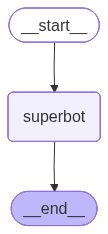

In [7]:
# Create nodes
graph = StateGraph(State)

# Node
graph.add_node("superbot", superbot)

# Edge
graph.add_edge(START, "superbot")
graph.add_edge("superbot", END)

graph_builder = graph.compile(checkpointer=memory)

# Display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [8]:
# Invoke
config = {"configurable": {"thread_id": "1"}}

graph_builder.invoke({"messages": "Hi, my name is Joe and I love cricket"}, config=config)

{'messages': [HumanMessage(content='Hi, my name is Joe and I love cricket', additional_kwargs={}, response_metadata={}, id='9c311084-0cfe-40af-810e-d24bbe6cbee5'),
  AIMessage(content='Nice to meet you, Joe. Cricket is an amazing sport with a huge following worldwide. What do you love most about cricket? Are you a fan of a particular team, player, or format of the game (Test, ODI, T20)? Do you play cricket yourself or just enjoy watching it?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 63, 'prompt_tokens': 45, 'total_tokens': 108, 'completion_time': 0.212342905, 'completion_tokens_details': None, 'prompt_time': 0.012583879, 'prompt_tokens_details': None, 'queue_time': 0.32240361, 'total_time': 0.224926784}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_f8b414701e', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f1189-8cc9-7303-957d-6b3895441b3b-0', tool_calls=[], i

## Streaming the responses with Stream Method

In [14]:
config = {"configurable": {"thread_id": "2"}}

for chunk in graph_builder.stream({"messages": "Hi, my name is Joe and I love cricket"}, config=config, stream_mode="updates"):
    print(chunk)

{'superbot': {'messages': [AIMessage(content='Hi Joe, great to meet you. Cricket is an amazing sport, and there are so many exciting moments to look forward to, from a perfectly placed cover drive to a dramatic caught-and-bowled. What is it about cricket that you love the most? Is it the strategy, the skill, or the thrill of competition?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 67, 'prompt_tokens': 448, 'total_tokens': 515, 'completion_time': 0.243298718, 'completion_tokens_details': None, 'prompt_time': 0.023151466, 'prompt_tokens_details': None, 'queue_time': 0.053054033, 'total_time': 0.266450184}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f118e-8663-7511-85a9-4ed9943ca3d1-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 448, 'output_tokens': 67, 'total_tokens': 515})]}}

In [15]:
config = {"configurable": {"thread_id": "2"}}

for chunk in graph_builder.stream({"messages": "I also like football"}, config=config, stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi, my name is Joe and I love cricket', additional_kwargs={}, response_metadata={}, id='29adba4e-fc96-4096-9b3d-3980bf81b00e'), AIMessage(content='Nice to meet you, Joe. Cricket is an exciting sport with a rich history and a massive following worldwide. What do you love most about cricket? Are you a fan of a particular team or player? Do you play the game yourself, or do you enjoy watching it?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 56, 'prompt_tokens': 45, 'total_tokens': 101, 'completion_time': 0.184317096, 'completion_tokens_details': None, 'prompt_time': 0.005651719, 'prompt_tokens_details': None, 'queue_time': 0.335022299, 'total_time': 0.189968815}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_f8b414701e', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f118b-4a92-7ed2-8b28-1b40dec4ff3f-0', tool_calls=[], invalid_tool_

In [16]:
for chunk in graph_builder.stream({"messages": "I also like baseball"}, config=config, stream_mode="updates"):
    print(chunk)

{'superbot': {'messages': [AIMessage(content="Joe, you're a triple threat in the sports world, with a love for cricket, football, and now baseball. That's a unique combination, but all three sports share a common thread - they're exciting, strategic, and require a high level of skill. Baseball, in particular, is a sport that's rich in history and tradition, with a huge following in the United States and around the world. Do you have a favorite baseball team or player, and have you ever had the chance to watch a live game at a stadium like Wrigley Field or Yankee Stadium?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 117, 'prompt_tokens': 611, 'total_tokens': 728, 'completion_time': 0.393323439, 'completion_tokens_details': None, 'prompt_time': 0.033779277, 'prompt_tokens_details': None, 'queue_time': 0.052637957, 'total_time': 0.427102716}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'fin

In [17]:
for chunk in graph_builder.stream({"messages": "I also like eating"}, config=config, stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi, my name is Joe and I love cricket', additional_kwargs={}, response_metadata={}, id='29adba4e-fc96-4096-9b3d-3980bf81b00e'), AIMessage(content='Nice to meet you, Joe. Cricket is an exciting sport with a rich history and a massive following worldwide. What do you love most about cricket? Are you a fan of a particular team or player? Do you play the game yourself, or do you enjoy watching it?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 56, 'prompt_tokens': 45, 'total_tokens': 101, 'completion_time': 0.184317096, 'completion_tokens_details': None, 'prompt_time': 0.005651719, 'prompt_tokens_details': None, 'queue_time': 0.335022299, 'total_time': 0.189968815}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_f8b414701e', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f118b-4a92-7ed2-8b28-1b40dec4ff3f-0', tool_calls=[], invalid_tool_

## Streaming the responses with astream Method

In [18]:
config = {"configurable": {"thread_id": "3"}}

async for event in graph_builder.astream_events({"messages": "Hi, my name is Joe and I love cricket"}, config=config, version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': 'Hi, my name is Joe and I love cricket'}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019f1195-f122-7df3-85d5-1a460b112008', 'metadata': {'thread_id': '3', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi, my name is Joe and I love cricket', additional_kwargs={}, response_metadata={}, id='e3e8f7ac-66d8-4a6a-9930-ebeb2acccec9')]}}, 'name': 'superbot', 'tags': ['graph:step:1'], 'run_id': '019f1195-f125-7793-935b-cd31ca634ff7', 'metadata': {'thread_id': '3', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'superbot', 'langgraph_triggers': ('branch:to:superbot',), 'langgraph_path': ('__pregel_pull', 'superbot'), 'langgraph_checkpoint_ns': 'superbot:c3ca5356-d691-8c0f-4774-0d440a35a845'}, 'parent_ids': ['019f1195-f122-7df3-85d5-1a460b112008']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages': [[HumanMessage(cont